# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [4]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [7]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)
print("THÔNG TIN CHUNG")
X_raw.info()

print("\nSỐ LƯỢNG MISSING VALUES")
print(X_raw.isnull().sum())

print(f"\nSố dòng trùng lặp trong dữ liệu gốc: {df.duplicated().sum()}")

print("\nSỐ LƯỢNG GIÁ TRỊ 0 TRONG TỪNG CỘT")
print((X_raw == 0).sum())

print('\nTHỐNG KÊ MÔ TẢ')
display(X_raw.describe().T)

THÔNG TIN CHUNG
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB

SỐ LƯỢNG MISSING VALUES
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Số dòng trùng lặp trong dữ liệu gốc: 0

SỐ LƯỢNG GIÁ TRỊ 0 TRONG TỪNG CỘT
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

THỐNG KÊ MÔ TẢ


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


- Mỗi dòng dữ liệu đại diện cho mức chi tiêu hằng năm của một khách hàng trên 6 features. CẢ 6 features đều có ý nghĩa cho segmentation vì phản ánh trực tiếp hành vi mua
- Không có missing value, không có duplicate, dữ liệu sai hay giá trị 0 ở mỗi cột, nhưng xuất hiện các điểm outliers rất lớn (vì cột q3 và max khác biệt rất lớn và mean lớn hơn rất nhiều với median)
- Biến channel/region không nên đưa vào input clustering ngay từ ban đầu vì khoảng cách Euclid hoạt động không tốt khi bị trộn lẫn các biến liên tục và biên pahn6 loại. Nên sử dụng khi ở bước kiểm tra các cụm
- Hữu ích trong business context có nghĩa là việc gom được các khách hàng thành các nhóm có hành vi rõ ràng

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

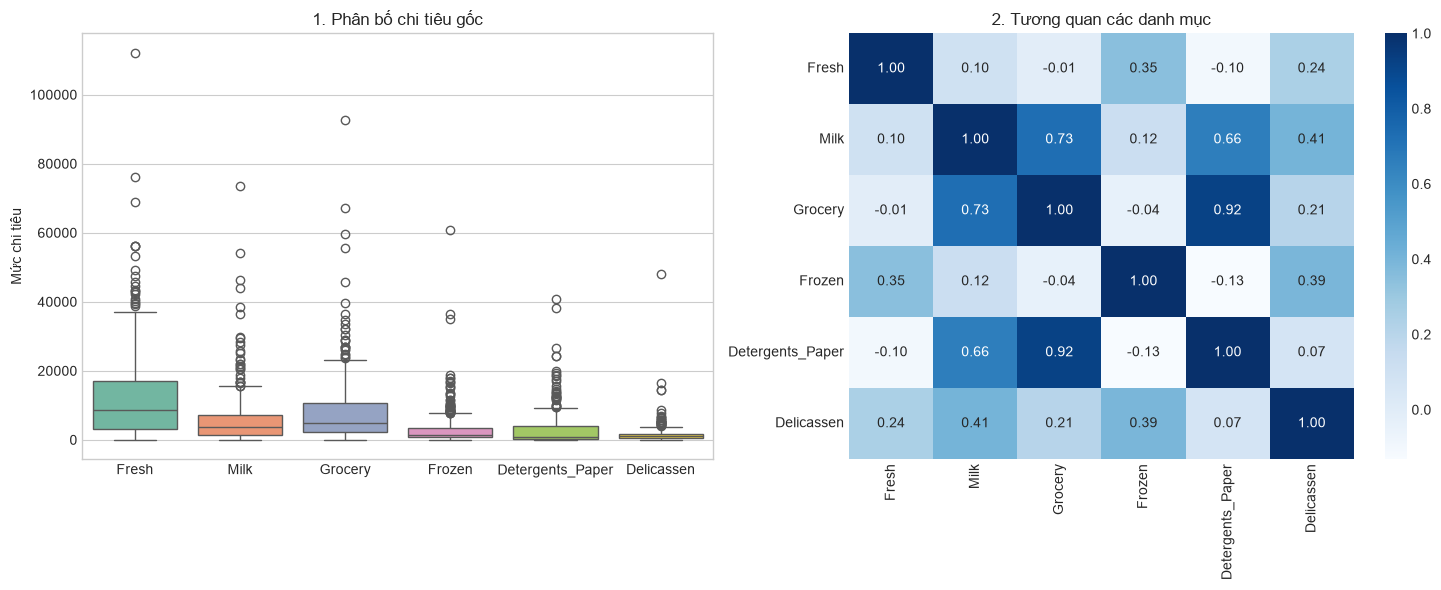

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize = (15,6))

sns.boxplot(data = X_raw, ax = axes[0], palette = 'Set2')
axes[0].set_title('1. Phân bố chi tiêu gốc')
axes[0].set_ylabel('Mức chi tiêu')

sns.heatmap(X_raw.corr(), annot = True, cmap = 'Blues', fmt = '.2f', ax = axes[1])
axes[1].set_title('2. Tương quan các danh mục')

plt.tight_layout()
plt.show()

- Có thể thấy dữ liệu bị lệch phải cực kỳ nặng ở tất cả các cột. Các điểm outliers sẽ làm sai lệch hoàn toàn việc tính khoảng cách, dẫn tới việc các thuật toán phân cụm bị nhiễu và dễ tạo ra các cụm chỉ chứa rất ít khách.
- Cột 'Fresh' và 'Grocery' có mức biến thiên mạnh nhất so với các features khác, trong khi 'Delicassen' và 'Frozen' có dải giá trị hẹp hơn rất nhiều. Ta cần phải đưa về cùng 1 tỉ lệ, vì nếu ko, model sẽ ưu tiên phân cụm dựa trên các cột có giá trị lớn và bỏ qua các cột nhỏ.
- Dựa vào heatmap, ta thấy 2 cặp: 'Grocery' - 'Detergents_Paper' (0.92) và 'Grocery' - 'Milk' (0.73) cho thấy mức tương quan rất cao, điều này có ý nghĩa là khi khách hàng mua tạp hóa thường sẽ mua kèm sữa và chất tẩy rửa
- Vì dữ liệu có quá nhiều outliers và bị lệch phải nặng nên ta bắt buộc phải có bước preprocessing để áp dụng K-Means, ta sẽ dùng phép biến đổi logarit và có thể dùng thêm 'StandardScaler' để đưa các cột về cùng thang đo.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [9]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))
from sklearn.preprocessing import StandardScaler
import numpy as np

X_model = StandardScaler().fit_transform(np.log1p(X_raw))

- Xử lý skew, outlier và khác biệt scale em đã sử dụng phép biến đổi np.log1p để nén các khoảng cách lớn, giảm mạnh độ lệch phải và kéo các outliers lại gần phân phối chung, cộng với việc sử dụng StandardScaler để chuẩn hóa tất cả các biến về cùng 1 thang đo. 
- Ta chọn X_model làm ma trận fit model vì các dữ liệu đã được scale và đưa về cùng 1 thang đo, như vậy thì các thuật toán sử dụng tính khoảng cách mới hoạt động tốt
- Việc sử dụng log1p và StandardScaler làm mất đi ý nghĩa trực quan của dữ liệu gốc. Các con số trong X_model hiện tại mang các giá trị âm dương lẫn lộn và không đại diện cho số tiền thực tế nữa. Do đó, ta không thể giải thích kết quả kinh doanh trực tiếp trên mô hình này nữa, mà phải gán nhãn cụm trở lại cho X_raw để làm profile bước cuối

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [11]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)
from sklearn.cluster import KMeans, DBSCAN
from collections import Counter

print('So sánh 2 thuật toán Clustering: K-Means và DBSCAN')

#K means
kmeans_model = KMeans(n_clusters = 5, n_init = 'auto', random_state=42)
labels_kmeans = kmeans_model.fit_predict(X_model)

print('K-Means')
print('Số lượng phần tử mỗi cụm:', dict(Counter(labels_kmeans)))

#Dbscan
dbscan_model = DBSCAN(eps = 1.2, min_samples=5)
labels_dbscan = dbscan_model.fit_predict(X_model)

print('\nDBSCAN')
print('Số lượng phần tử mỗi cụm:', dict(Counter(labels_dbscan)))

So sánh 2 thuật toán Clustering: K-Means và DBSCAN
K-Means
Số lượng phần tử mỗi cụm: {np.int32(4): 83, np.int32(2): 92, np.int32(1): 147, np.int32(3): 85, np.int32(0): 33}

DBSCAN
Số lượng phần tử mỗi cụm: {np.int64(0): 361, np.int64(-1): 79}


K-means:
+ Input và tham số: X_model, n_clusters, n_init, random_state
+ Kết quả: Dữ liệu được chia làm 5 cụm với kích thước tương đối
+ K-Means xử lý tốt do dữ liệu đã được nén bằng log và chuẩn hóa bằng StandardScaler
+ Quyết định giữ lại để tinh chỉnh tham số ở bước tiếp theo

DBSCAN:
+ Input và tham số: X_model, eps và min_samples
+ Kết quả: DBSCAN tạo ra 2 cụm, 1 cụm với số phần tử cực kỳ lớn so với cụm còn lại, có tỉ lệ nhiễu khá lớn
+ Dù đã chuẩn hóa, DBSCAN gặp khó khăn với loại dữ liệu không đồng đều và liên tục như thế này
+ Quyết định loại bỏ vì cụm không tạo ra giá trị phân loại hữu ích cho business

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

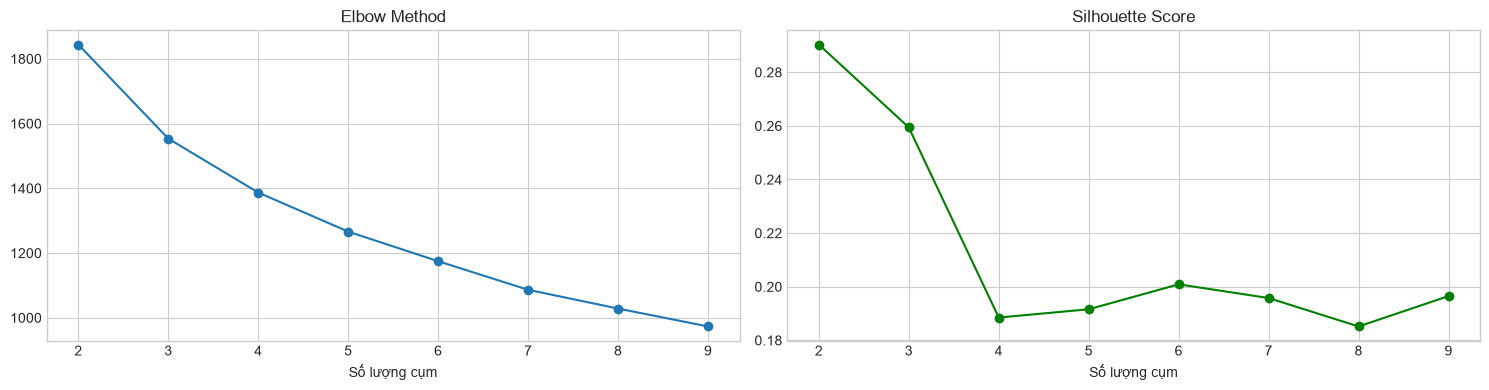


[STABILITY TEST] Điểm ARI khi thay đổi random seed: 0.9785


In [15]:
from sklearn.metrics import silhouette_samples, adjusted_rand_score

#Tìm số cụm K tối ưu
k_values = range(2,10)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init = 10, random_state=42)
    labels = kmeans.fit_predict(X_model)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_model, labels))

fig, axes = plt.subplots(1,2,figsize=(15,4))
axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Số lượng cụm')

axes[1].plot(k_values, silhouette_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Số lượng cụm')

plt.tight_layout()
plt.show()

#Chọn model cuối cùng
final_model = KMeans(n_clusters=5, n_init=10, random_state=42)
labels_final = final_model.fit_predict(X_model)

test_model = KMeans(n_clusters=5, n_init=10, random_state=999)
labels_test = test_model.fit_predict(X_model)

ari = adjusted_rand_score(labels_final, labels_test)
print(f"\n[STABILITY TEST] Điểm ARI khi thay đổi random seed: {ari:.4f}")

- Dựa vào biểu đồ, chỉ số Silhouette đạt cao nhất ở k = 2, nhưng việc chia toàn bộ khách hàng thành 2 nhóm là quá bao quát. Em chọn k = 4 hoặc 5 vì Inertia giảm tốt và điểm Silhouette vẫn ở mức chấp nhận được
- Về tính stability/robustness, em thay đổi random_state từ 42 sang 999, kết quả so sánh cho ra chỉ số ARI đạt mức rất cao, tận 0.9785, điều này chứng tỏ K-Means hội tụ rất ổn định trên dữ liệu đã chuẩn hóa
- Dù điểm số toán học dựa trên 2 metric là Inertia và Silhouette tốt nhưng cần check profile để xem 5 cụm có đại diện cho 5 hành vi mua hàng thực tế hay không

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


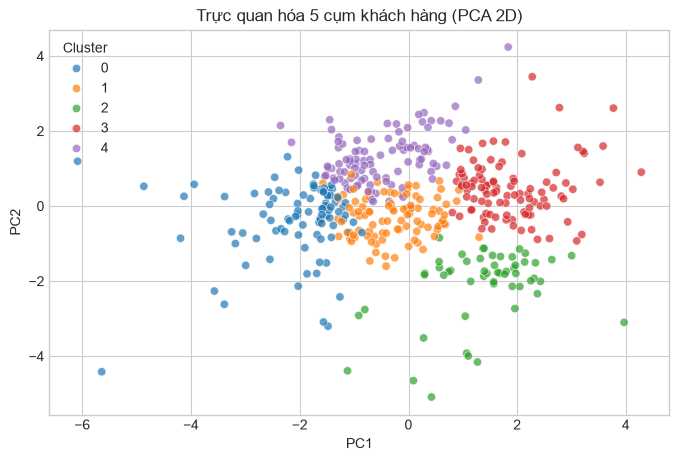

In [16]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_model)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels_final

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title('Trực quan hóa 5 cụm khách hàng (PCA 2D)')
plt.show()

- Nhìn vào biểu đồ 2D, ta có thể thấy sự phân tách tương đối giữa các nhóm khách hàng, chứng minh thuật toán đã gom được các cụm có hành vi khác biệt nhau
- Tuy vậy, biểu đồ này không đại diện cho không gian 6 chiều thực sự, việc có các điểm đè lên nhau trên hình 2D không có nghĩa là model sai và biểu đồ 2D chỉ để minh họa, không dùng để đo khoảng cách chính xác

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

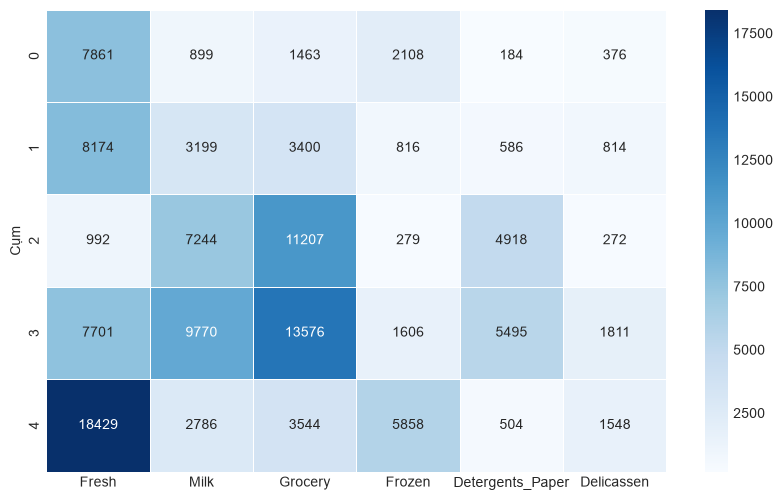

In [25]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()

profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()

plt.figure(figsize = (10,6))
sns.heatmap(profile, annot = True, fmt = '.0f', cmap = 'Blues', linewidths=.5)

plt.ylabel('Cụm')
plt.show()

- Profile được xây dựng trên dữ liệu gốc bằng cách sử dụng giá trị trung vị để đảm bảo chân dung cụm mô tả đúng số đông mà không bị kéo lệch bởi các điểm cực trị
- Ta có thể nhận diện cấu trúc từng cụm dựa trên pattern trên nhiều feature: 
  + Cụm 0: chi tiêu tập trung vào 'Fresh' và 'Frozen'
  + Cụm 1: Chi tiêu rất nhiều vào 'Fresh', 'Milk' và 'Grocery'
  + Cụm 2: Chuyên mua các đồ 'Grocery', 'Milk' và 'Detergents_Paper' và tỉ lệ nhỏ mua các features còn lại
  + Cụm 3: Khách khủng, chi tiêu đa dạng và mua số lượng lớn
  + Cụm 4: Khách hàng chuyên mua đồ tươi sống, nhưng các mặt hàng còn lại lại khá khiêm tốn
- Theo em, có lẽ ta cần tối ưu phân phối hàng hóa 'Fresh' cho cụm 4 vì cụm này đang xây dựng lợi thế cực kỳ lớn về chi tiêu thực phẩm sạch, mới. Và với các cụm 2, 3 có điểm chung là chi tiêu tập trung vào 'Grocery', 'Milk' và 'Detergents_Paper' thì doanh nghiệp có thể thiết kế các chương trình chiết khấu mua kèm cho nhóm này để tăng doanh thu đồng đều 3 nhánh hàng.
- Trước khi biến giải thuyết thành công, ta cần thêm 1 số dữ liệu để kiểm chứng. Đầu tiên là tỷ suất lợi nhuận, ví dụ như việc vận chuẩn 'Fresh
 tốn quá nhiều chi phí thì chưa chắc việc đầu tư vào nó sẽ có lợi thế. Thứ 2 là tần suất mua hàng của các cụm nhỏ như 0, 1 để đánh giá chi phí vận hành có bị lãng phí hay không.


# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

1. Nên thử nghiệm giới hạn segmentation này trên các chiến dịch marketing nhỏ trước khi áp dụng toàn diện. Tuy mô hình đã phân tách rõ các hành vi cốt lõi nhưng cần dữ liệu thực tế để kiểm chứng
2. 
- Preprocessing bằng log1p và StandardScaler để xử lý hiện tượng dữ liệu bị lệch phải nặng và chứa quá nhiều outliers
- Dùng model K-Means với k = 5 có chỉ số ổn định ARI cực cao, kết hợp với điểm Silhouette cho thấy 5 cụm có ranh giới phân tách rất tốt
3. 2 insight quan trọng nhất:
- Sự phân hóa rõ rệt giữa 2 nhóm khách hàng: Nhóm chuyên mua tạp hóa/đồ khô và nhóm chuyên mua đồ tươi sống
- Có 1 nhóm khách hàng chi tiêu cực thấp ở mọi danh mục cho thấy chi phí phục vụ tệp khách hàng này có thể đang ăn lạm vào lợi nhuận
4. Chạy chiến dịch khuyến mãi chéo: Mua 5 lốc sữa, giảm 10% hộp khô gà để nhắm vào cụm tạp hóa. Đánh giá thành công thông qua chỉ số ROI của chiến dịch và tỷ lệ Lift trong chi tiêu mảng chất tẩy rửa so với tháng trước
5. Thuật toán K-Means hoạt động trên không gian chuẩn hóa nên mất đi ý nghĩa tỉ lệ tiền thực tế, ngoài ra việc thiếu dữ liệu ngữ cảnh (lợi nhuận, tần suất mua,...) khiến các cụm chỉ đang phản ánh 'Độ lớn giỏi hàng' hơn là phản ánh 'Giá trị trọn đời' của khách

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.